# 04 — Two-lane sensitivity (homogeneous, p_chg = 0.3)

Two-lane parity of `nagel_sensitivity.ipynb`. All sweeps use homogeneous traffic (`f_slow = 0`) and the standard two-lane open-boundary protocol with traffic lights. Heterogeneity sweeps live in 05.

Phase-offset (φ) sensitivity is in **02**; we don't reproduce it. Mixed-traffic results are in **05**.

**Cache convention** — every `.npz` preserves the full per-seed shape `(n_..., n_seeds)` so SD bands are recomputed at plot time, not at save time.

In [1]:
%load_ext autoreload
%autoreload 2

import os, time, numpy as np, matplotlib.pyplot as plt
from tqdm.auto import tqdm

from nasch_two_lane import TwoLaneNaSch, TwoLaneNaSchWithLights

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

DATA_DIR = '../data'
FIGURES_DIR = '../figures'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ─── Global parameters ────────────────────────────────────────────
L            = 500
V_MAX        = 5
P_RAND       = 0.3
P_IN         = 0.4
T_WARMUP     = 3000
T_MEASURE    = 6000
N_SEEDS      = 3
PCHG_DEFAULT = 0.3
SEEDS        = np.arange(N_SEEDS)
V_FREE       = V_MAX - P_RAND   # canonical free-flow speed

# Cache convention: per-seed shape preserved so SD bands can be
# regenerated without resimulating.

def load_or_compute(path, compute_fn, force=False):
    """Load `path` if it exists; else compute, save, and return."""
    if force or not os.path.exists(path):
        result = compute_fn()
        np.savez(path, **result)
        return result
    with np.load(path) as f:
        return {k: f[k] for k in f.files}

def greenwave_offsets(N, T_cycle, v_free=V_FREE, L_road=L):
    """Phase offsets that align consecutive lights at v_free."""
    s = L_road / (N + 1)
    return np.array([int(round((i * s / v_free) % T_cycle))
                     for i in range(N)])

def measure_J(sim, T_warmup, T_measure):
    """Open-boundary throughput: outflow per timestep across both lanes."""
    sim.warmup(T_warmup)
    return sim.run(T_measure)

print(f'L={L}, v_max={V_MAX}, p_rand={P_RAND}, p_in={P_IN}')
print(f'T_warmup={T_WARMUP}, T_measure={T_MEASURE}, n_seeds={N_SEEDS}')
print(f'v_free (canonical) = {V_FREE}')


Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen impor

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstra

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importl

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<fr

L=500, v_max=5, p_rand=0.3, p_in=0.4
T_warmup=3000, T_measure=6000, n_seeds=3
v_free (canonical) = 4.7


## §2 — Throughput vs N (number of lights)

Sweep `N ∈ {1, 2, 3, 4, 5, 6, 8, 10}` for two coordination strategies: **sync** (all lights at phase 0) and **offset** (greenwave at v_free). Fixed `T_cycle = 60`, `T_green = 30`.

In [2]:
N_GRID = np.array([1, 2, 3, 4, 5, 6, 8, 10])
STRATEGIES = ['sync', 'offset']
T_CYCLE_S2 = 60
T_GREEN_S2 = 30

def compute_J_vs_N():
    flow = np.zeros((len(N_GRID), len(STRATEGIES), N_SEEDS))
    t0 = time.time()
    for ni, N in enumerate(tqdm(N_GRID, desc='N')):
        for si, strategy in enumerate(STRATEGIES):
            phi = (np.zeros(N, dtype=int) if strategy == 'sync'
                   else greenwave_offsets(N, T_CYCLE_S2))
            for ki, seed in enumerate(SEEDS):
                np.random.seed(seed)
                sim = TwoLaneNaSchWithLights(
                    L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                    p_chg=PCHG_DEFAULT, boundary='open', p_in=P_IN,
                    N=int(N), T_cycle=T_CYCLE_S2, T_green=T_GREEN_S2,
                    phase_offsets=phi,
                )
                flow[ni, si, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, N_grid=N_GRID, strategies=np.array(STRATEGIES),
                seeds=SEEDS, T_cycle=T_CYCLE_S2, T_green=T_GREEN_S2,
                T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S2 = load_or_compute(f'{DATA_DIR}/04_J_vs_N.npz', compute_J_vs_N)
print(f'wall-clock: {float(S2["wall_clock"]):.1f} s')


wall-clock: 1748.7 s


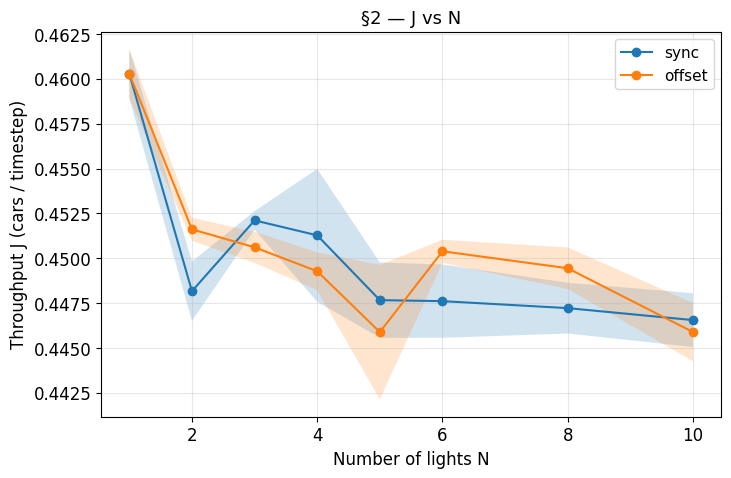

In [3]:
fig, ax = plt.subplots()
for si, strat in enumerate(STRATEGIES):
    m = S2['flow'][:, si, :].mean(axis=-1)
    s = S2['flow'][:, si, :].std(axis=-1)
    ax.plot(S2['N_grid'], m, '-o', label=strat)
    ax.fill_between(S2['N_grid'], m - s, m + s, alpha=0.2)
ax.set_xlabel('Number of lights N')
ax.set_ylabel('Throughput J (cars / timestep)')
ax.set_title('§2 — J vs N')
ax.legend()
fig.savefig(f'{FIGURES_DIR}/04_J_vs_N.png')
plt.show()


**Figure 04.2 — Throughput vs number of lights.** Two-lane open boundary with `L=500, v_max=5, p_rand=0.3, p_in=0.4, p_chg=0.3, T_cycle=60, T_green=30, n_seeds=3, T_warmup=3000, T_measure=6000`. Solid curves are mean over seeds; shaded bands are ±1 SD. Sync = all lights in phase; offset = greenwave at v_free = 4.7.

## §3 — Throughput vs T_cycle

Sweep `T_cycle ∈ {10, 20, 30, 40, 60, 80, 100, 150}`. Fixed `N=2`, green fraction = 0.5, greenwave offset. Vertical dashed line marks the theoretical resonance `T_cycle = 2·d/v_free` where d = L/(N+1).

In [4]:
TC_GRID = np.array([10, 20, 30, 40, 60, 80, 100, 150])
N_S3 = 2

def compute_J_vs_Tcycle():
    flow = np.zeros((len(TC_GRID), N_SEEDS))
    t0 = time.time()
    for ti, Tc in enumerate(tqdm(TC_GRID, desc='Tc')):
        T_green = int(Tc) // 2
        phi = greenwave_offsets(N_S3, int(Tc))
        for ki, seed in enumerate(SEEDS):
            np.random.seed(seed)
            sim = TwoLaneNaSchWithLights(
                L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                p_chg=PCHG_DEFAULT, boundary='open', p_in=P_IN,
                N=N_S3, T_cycle=int(Tc), T_green=T_green,
                phase_offsets=phi,
            )
            flow[ti, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, T_cycle_grid=TC_GRID, seeds=SEEDS,
                N=N_S3, T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S3 = load_or_compute(f'{DATA_DIR}/04_J_vs_Tcycle.npz', compute_J_vs_Tcycle)
print(f'wall-clock: {float(S3["wall_clock"]):.1f} s')


wall-clock: 858.0 s


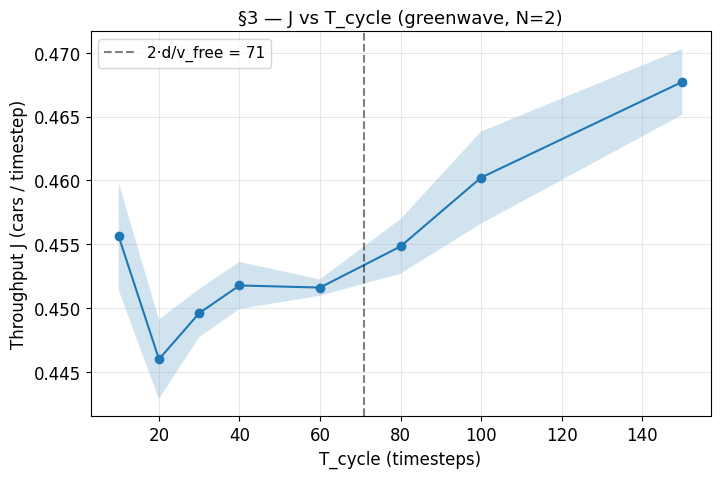

In [5]:
fig, ax = plt.subplots()
m = S3['flow'].mean(axis=-1)
s = S3['flow'].std(axis=-1)
ax.plot(S3['T_cycle_grid'], m, '-o')
ax.fill_between(S3['T_cycle_grid'], m - s, m + s, alpha=0.2)
d = L / (N_S3 + 1)
Tc_resonance = 2 * d / V_FREE
ax.axvline(Tc_resonance, color='k', linestyle='--', alpha=0.5,
           label=f'2·d/v_free = {Tc_resonance:.0f}')
ax.set_xlabel('T_cycle (timesteps)')
ax.set_ylabel('Throughput J (cars / timestep)')
ax.set_title('§3 — J vs T_cycle (greenwave, N=2)')
ax.legend()
fig.savefig(f'{FIGURES_DIR}/04_J_vs_Tcycle.png')
plt.show()


## §4 — Throughput vs green fraction

Sweep `T_green / T_cycle ∈ {0.1, ..., 0.9}` at fixed `N=2`, `T_cycle=60`, greenwave offset.

In [6]:
GF_GRID = np.arange(0.1, 0.95, 0.1)
T_CYCLE_S4 = 60
N_S4 = 2

def compute_J_vs_green():
    flow = np.zeros((len(GF_GRID), N_SEEDS))
    t0 = time.time()
    phi = greenwave_offsets(N_S4, T_CYCLE_S4)
    for gi, gf in enumerate(tqdm(GF_GRID, desc='gf')):
        T_green = max(1, int(round(gf * T_CYCLE_S4)))
        for ki, seed in enumerate(SEEDS):
            np.random.seed(seed)
            sim = TwoLaneNaSchWithLights(
                L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                p_chg=PCHG_DEFAULT, boundary='open', p_in=P_IN,
                N=N_S4, T_cycle=T_CYCLE_S4, T_green=T_green,
                phase_offsets=phi,
            )
            flow[gi, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, green_frac_grid=GF_GRID, seeds=SEEDS,
                N=N_S4, T_cycle=T_CYCLE_S4,
                T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S4 = load_or_compute(f'{DATA_DIR}/04_J_vs_green.npz', compute_J_vs_green)
print(f'wall-clock: {float(S4["wall_clock"]):.1f} s')


wall-clock: 874.9 s


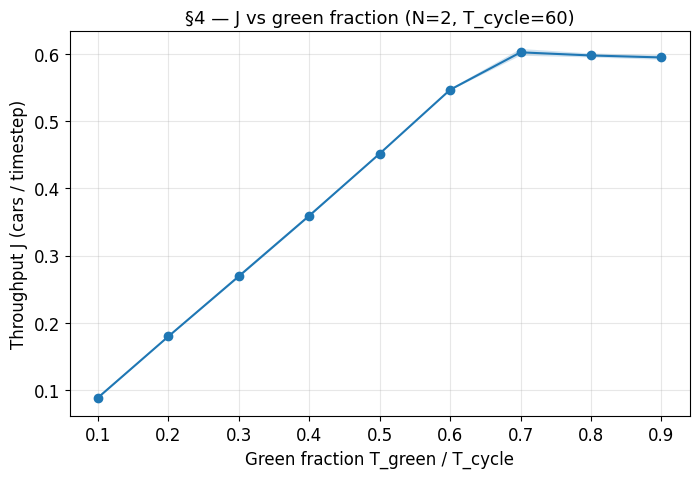

In [7]:
fig, ax = plt.subplots()
m = S4['flow'].mean(axis=-1)
s = S4['flow'].std(axis=-1)
ax.plot(S4['green_frac_grid'], m, '-o')
ax.fill_between(S4['green_frac_grid'], m - s, m + s, alpha=0.2)
ax.set_xlabel('Green fraction T_green / T_cycle')
ax.set_ylabel('Throughput J (cars / timestep)')
ax.set_title('§4 — J vs green fraction (N=2, T_cycle=60)')
fig.savefig(f'{FIGURES_DIR}/04_J_vs_green.png')
plt.show()


## §5 — Throughput vs v_max

Sweep `v_max ∈ {1, 2, 3, 5, 7, 10}` at fixed `N=2, T_cycle=60, T_green=30`, greenwave offset.

In [8]:
VMAX_GRID = np.array([1, 2, 3, 5, 7, 10])
T_CYCLE_S5 = 60
T_GREEN_S5 = 30
N_S5 = 2

def compute_J_vs_vmax():
    flow = np.zeros((len(VMAX_GRID), N_SEEDS))
    t0 = time.time()
    for vi, vm in enumerate(tqdm(VMAX_GRID, desc='vmax')):
        v_free_local = max(0.1, vm - P_RAND)
        phi = np.array([int(round((i * (L / (N_S5 + 1)) / v_free_local) % T_CYCLE_S5))
                        for i in range(N_S5)])
        for ki, seed in enumerate(SEEDS):
            np.random.seed(seed)
            sim = TwoLaneNaSchWithLights(
                L=L, n_lanes=2, v_max=int(vm), p_rand=P_RAND,
                p_chg=PCHG_DEFAULT, boundary='open', p_in=P_IN,
                N=N_S5, T_cycle=T_CYCLE_S5, T_green=T_GREEN_S5,
                phase_offsets=phi,
            )
            flow[vi, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, vmax_grid=VMAX_GRID, seeds=SEEDS,
                T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S5 = load_or_compute(f'{DATA_DIR}/04_J_vs_vmax.npz', compute_J_vs_vmax)
print(f'wall-clock: {float(S5["wall_clock"]):.1f} s')


vmax:   0%|          | 0/6 [00:00<?, ?it/s]

wall-clock: 187.8 s


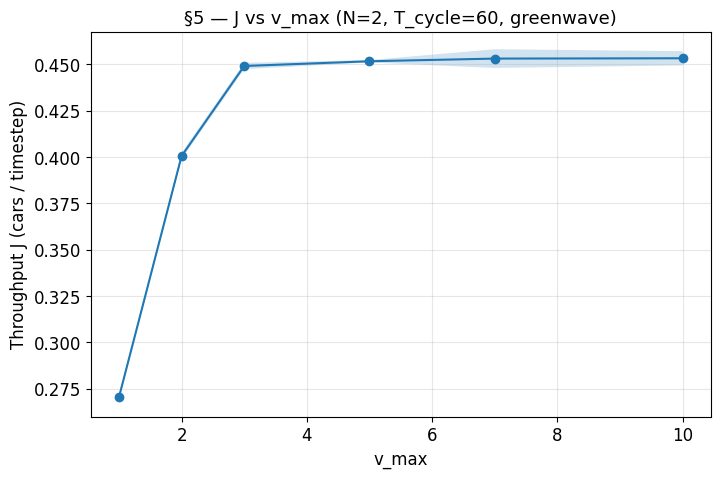

In [9]:
fig, ax = plt.subplots()
m = S5['flow'].mean(axis=-1)
s = S5['flow'].std(axis=-1)
ax.plot(S5['vmax_grid'], m, '-o')
ax.fill_between(S5['vmax_grid'], m - s, m + s, alpha=0.2)
ax.set_xlabel('v_max')
ax.set_ylabel('Throughput J (cars / timestep)')
ax.set_title('§5 — J vs v_max (N=2, T_cycle=60, greenwave)')
fig.savefig(f'{FIGURES_DIR}/04_J_vs_vmax.png')
plt.show()


## §6 — (N, T_cycle) optimisation heatmap

2D sweep `N × T_cycle ∈ {1..5} × {10, 20, 40, 60, 100}`. Fixed green fraction = 0.5, greenwave offset. Mean J reported with empirical argmax marked.

In [10]:
N_GRID_S6 = np.array([1, 2, 3, 4, 5])
TC_GRID_S6 = np.array([10, 20, 40, 60, 100])

def compute_heatmap():
    flow = np.zeros((len(N_GRID_S6), len(TC_GRID_S6), N_SEEDS))
    t0 = time.time()
    for ni, N in enumerate(tqdm(N_GRID_S6, desc='N')):
        for ti, Tc in enumerate(TC_GRID_S6):
            phi = greenwave_offsets(int(N), int(Tc))
            for ki, seed in enumerate(SEEDS):
                np.random.seed(seed)
                sim = TwoLaneNaSchWithLights(
                    L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                    p_chg=PCHG_DEFAULT, boundary='open', p_in=P_IN,
                    N=int(N), T_cycle=int(Tc), T_green=int(Tc) // 2,
                    phase_offsets=phi,
                )
                flow[ni, ti, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, N_grid=N_GRID_S6, T_cycle_grid=TC_GRID_S6,
                seeds=SEEDS, T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S6 = load_or_compute(f'{DATA_DIR}/04_heatmap_N_Tcycle.npz', compute_heatmap)
print(f'wall-clock: {float(S6["wall_clock"]):.1f} s')


N:   0%|          | 0/5 [00:00<?, ?it/s]

wall-clock: 447.0 s


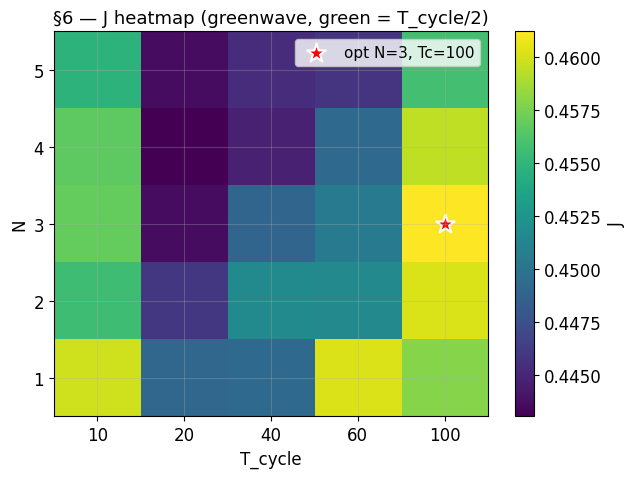

argmax: N=3, T_cycle=100, J=0.4612


In [11]:
mean_flow = S6['flow'].mean(axis=-1)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(mean_flow, aspect='auto', origin='lower',
                cmap='viridis')
ax.set_xticks(np.arange(len(S6['T_cycle_grid'])))
ax.set_xticklabels(S6['T_cycle_grid'])
ax.set_yticks(np.arange(len(S6['N_grid'])))
ax.set_yticklabels(S6['N_grid'])
ax.set_xlabel('T_cycle')
ax.set_ylabel('N')
ax.set_title('§6 — J heatmap (greenwave, green = T_cycle/2)')
argmax = np.unravel_index(np.argmax(mean_flow), mean_flow.shape)
ax.scatter([argmax[1]], [argmax[0]], marker='*', s=200,
            color='red', edgecolor='white', linewidth=1.5,
            label=f'opt N={int(S6["N_grid"][argmax[0]])}, '
                  f'Tc={int(S6["T_cycle_grid"][argmax[1]])}')
fig.colorbar(im, ax=ax, label='J')
ax.legend(loc='upper right')
fig.savefig(f'{FIGURES_DIR}/04_heatmap_N_Tcycle.png')
plt.show()
print(f'argmax: N={int(S6["N_grid"][argmax[0]])}, '
      f'T_cycle={int(S6["T_cycle_grid"][argmax[1]])}, '
      f'J={mean_flow[argmax]:.4f}')


## §7 — Sensitivity to p_rand

Sweep `p_rand ∈ {0.0, 0.1, 0.2, 0.3, 0.5}`. Fixed `N=2, T_cycle=60, T_green=30`, greenwave offset (recomputed at each p_rand because v_free shifts with p_rand).

In [12]:
PRAND_GRID = np.array([0.0, 0.1, 0.2, 0.3, 0.5])
T_CYCLE_S7 = 60
T_GREEN_S7 = 30
N_S7 = 2

def compute_J_vs_prand():
    flow = np.zeros((len(PRAND_GRID), N_SEEDS))
    t0 = time.time()
    for pi, pr in enumerate(tqdm(PRAND_GRID, desc='p_rand')):
        v_free_local = max(0.1, V_MAX - pr)
        phi = np.array([int(round((i * (L / (N_S7 + 1)) / v_free_local) % T_CYCLE_S7))
                        for i in range(N_S7)])
        for ki, seed in enumerate(SEEDS):
            np.random.seed(seed)
            sim = TwoLaneNaSchWithLights(
                L=L, n_lanes=2, v_max=V_MAX, p_rand=float(pr),
                p_chg=PCHG_DEFAULT, boundary='open', p_in=P_IN,
                N=N_S7, T_cycle=T_CYCLE_S7, T_green=T_GREEN_S7,
                phase_offsets=phi,
            )
            flow[pi, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, prand_grid=PRAND_GRID, seeds=SEEDS,
                T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S7 = load_or_compute(f'{DATA_DIR}/04_J_vs_prand.npz', compute_J_vs_prand)
print(f'wall-clock: {float(S7["wall_clock"]):.1f} s')


p_rand:   0%|          | 0/5 [00:00<?, ?it/s]

wall-clock: 66.1 s


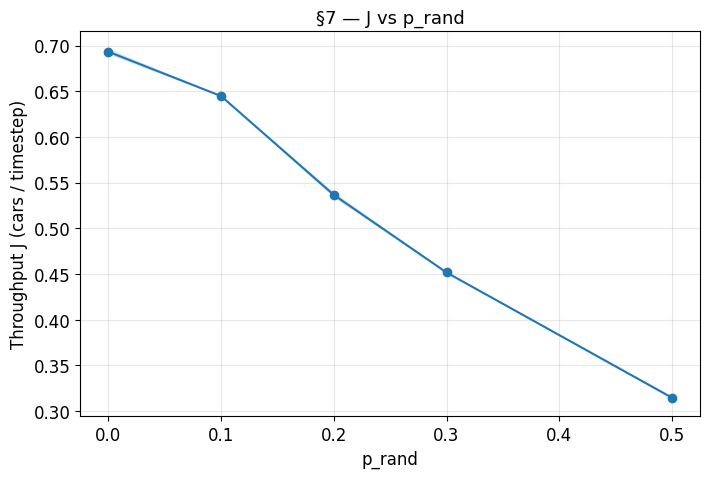

In [13]:
fig, ax = plt.subplots()
m = S7['flow'].mean(axis=-1)
s = S7['flow'].std(axis=-1)
ax.plot(S7['prand_grid'], m, '-o')
ax.fill_between(S7['prand_grid'], m - s, m + s, alpha=0.2)
ax.set_xlabel('p_rand')
ax.set_ylabel('Throughput J (cars / timestep)')
ax.set_title('§7 — J vs p_rand')
fig.savefig(f'{FIGURES_DIR}/04_J_vs_prand.png')
plt.show()


## §8 — Sensitivity to p_chg

Sweep `p_chg ∈ {0.0, 0.1, 0.2, 0.3, 0.5, 1.0}`. Fixed `N=2, T_cycle=60, T_green=30`, greenwave offset. Reference horizontal at `p_chg = 0` shows the no-lane-change baseline.

In [14]:
PCHG_GRID = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 1.0])
T_CYCLE_S8 = 60
T_GREEN_S8 = 30
N_S8 = 2

def compute_J_vs_pchg():
    flow = np.zeros((len(PCHG_GRID), N_SEEDS))
    t0 = time.time()
    phi = greenwave_offsets(N_S8, T_CYCLE_S8)
    for ci, pc in enumerate(tqdm(PCHG_GRID, desc='p_chg')):
        for ki, seed in enumerate(SEEDS):
            np.random.seed(seed)
            sim = TwoLaneNaSchWithLights(
                L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                p_chg=float(pc), boundary='open', p_in=P_IN,
                N=N_S8, T_cycle=T_CYCLE_S8, T_green=T_GREEN_S8,
                phase_offsets=phi,
            )
            flow[ci, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, pchg_grid=PCHG_GRID, seeds=SEEDS,
                T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S8 = load_or_compute(f'{DATA_DIR}/04_J_vs_pchg.npz', compute_J_vs_pchg)
print(f'wall-clock: {float(S8["wall_clock"]):.1f} s')


p_chg:   0%|          | 0/6 [00:00<?, ?it/s]

wall-clock: 76.0 s


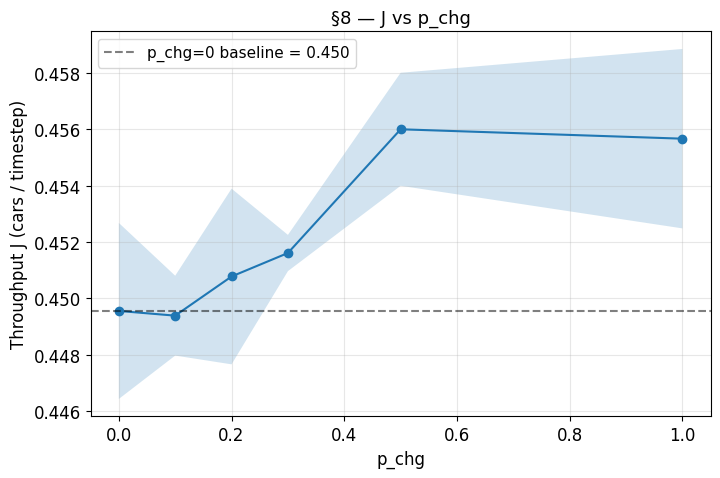

In [15]:
fig, ax = plt.subplots()
m = S8['flow'].mean(axis=-1)
s = S8['flow'].std(axis=-1)
ax.plot(S8['pchg_grid'], m, '-o')
ax.fill_between(S8['pchg_grid'], m - s, m + s, alpha=0.2)
ax.axhline(m[0], linestyle='--', color='k', alpha=0.5,
           label=f'p_chg=0 baseline = {m[0]:.3f}')
ax.set_xlabel('p_chg')
ax.set_ylabel('Throughput J (cars / timestep)')
ax.set_title('§8 — J vs p_chg')
ax.legend()
fig.savefig(f'{FIGURES_DIR}/04_J_vs_pchg.png')
plt.show()


## §9 — Robustness of the optimum to p_chg

Recompute the §6 grid at `p_chg ∈ {0, 0.3}` only. Report the difference heatmap; small magnitudes confirm the optimum is robust to lane-changing.

In [16]:
PCHG_PAIR = np.array([0.0, 0.3])

def compute_robustness():
    flow = np.zeros((len(N_GRID_S6), len(TC_GRID_S6), len(PCHG_PAIR), N_SEEDS))
    t0 = time.time()
    for ni, N in enumerate(tqdm(N_GRID_S6, desc='N')):
        for ti, Tc in enumerate(TC_GRID_S6):
            phi = greenwave_offsets(int(N), int(Tc))
            for pi, pc in enumerate(PCHG_PAIR):
                for ki, seed in enumerate(SEEDS):
                    np.random.seed(seed)
                    sim = TwoLaneNaSchWithLights(
                        L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                        p_chg=float(pc), boundary='open', p_in=P_IN,
                        N=int(N), T_cycle=int(Tc), T_green=int(Tc) // 2,
                        phase_offsets=phi,
                    )
                    flow[ni, ti, pi, ki] = measure_J(sim, T_WARMUP, T_MEASURE)
    return dict(flow=flow, N_grid=N_GRID_S6, T_cycle_grid=TC_GRID_S6,
                pchg_pair=PCHG_PAIR, seeds=SEEDS,
                T_warmup=T_WARMUP, T_measure=T_MEASURE,
                wall_clock=time.time() - t0)

S9 = load_or_compute(f'{DATA_DIR}/04_robustness_pchg.npz', compute_robustness)
print(f'wall-clock: {float(S9["wall_clock"]):.1f} s')


N:   0%|          | 0/5 [00:00<?, ?it/s]

wall-clock: 448.9 s


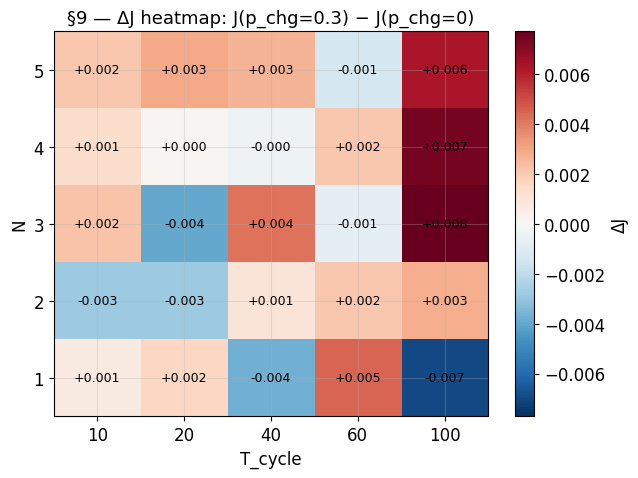

max |ΔJ| = 0.0077


In [17]:
delta = S9['flow'][:, :, 1, :].mean(axis=-1) - S9['flow'][:, :, 0, :].mean(axis=-1)
fig, ax = plt.subplots(figsize=(7, 5))
vlim = float(np.max(np.abs(delta)))
im = ax.imshow(delta, aspect='auto', origin='lower',
                cmap='RdBu_r', vmin=-vlim, vmax=vlim)
for i in range(len(S9['N_grid'])):
    for j in range(len(S9['T_cycle_grid'])):
        ax.text(j, i, f'{delta[i, j]:+.3f}', ha='center', va='center',
                fontsize=9)
ax.set_xticks(np.arange(len(S9['T_cycle_grid'])))
ax.set_xticklabels(S9['T_cycle_grid'])
ax.set_yticks(np.arange(len(S9['N_grid'])))
ax.set_yticklabels(S9['N_grid'])
ax.set_xlabel('T_cycle')
ax.set_ylabel('N')
ax.set_title('§9 — ΔJ heatmap: J(p_chg=0.3) − J(p_chg=0)')
fig.colorbar(im, ax=ax, label='ΔJ')
fig.savefig(f'{FIGURES_DIR}/04_robustness_pchg.png')
plt.show()
print(f'max |ΔJ| = {vlim:.4f}')


## Summary

Notebook 04 is a homogeneous two-lane parity of `nagel_sensitivity.ipynb`. It sweeps the same axes (N, T_cycle, green fraction, v_max, p_rand) plus a two-lane-specific p_chg sweep, an N×T_cycle heatmap, and a robustness check. Cached arrays preserve per-seed shape so SD bands are recomputed at plot time.